# Generate pairs of images for mat and camera frames.

In [16]:
import os
import datetime
from zoneinfo import ZoneInfo
import pandas as pd
import numpy as np
# import ffmpeg
import PIL
from PIL import Image
from PIL import ImageOps
# from PIL import Resampling
from matplotlib import cm
import csv
import re

Magic number for image alignment.

In [3]:
camera_image_width, camera_image_height = 80, 60
# camera_image_rescale = 1.5

mat_image_width, mat_image_height = 27, 64
# camera_min_value, camera_max_value = 7886.0, 8171.0

In [4]:
def mat_date_reader(d):
    """Read the timestamp in a mat csv file"""
    try:
        return datetime.datetime.strptime(d, '%Y-%m-%dT%H:%M:%S.%f%z')
    except ValueError:
        try: 
            return datetime.datetime.strptime(d, '%Y-%m-%dT%H:%M:%S%z')
        except ValueError:
            try:
                return datetime.datetime.strptime(d, '%Y-%m-%d %H:%M:%S.%f%z')
            except ValueError:
                return datetime.datetime.strptime(d, '%Y-%m-%d %H:%M:%S%z')

In [5]:
def camera_date_reader(d):
    try:
        return datetime.datetime.strptime(d, 'frame_%Y-%m-%dT%H_%M_%S.%f.csv')
    except ValueError:
        return datetime.datetime.strptime(d, 'frame_%Y-%m-%dT%H_%M_%S.csv')

In [8]:
with open('training_frames.csv', 'r', newline='') as f:
    reader = csv.DictReader(f)
    training_data_frames = [row for row in reader]
len(training_data_frames)

12603

In [10]:
with open('validation_frames.csv', 'r', newline='') as f:
    reader = csv.DictReader(f)
    validation_data_frames = [row for row in reader]
len(validation_data_frames)

840

In [11]:
with open('testing_frames.csv', 'r', newline='') as f:
    reader = csv.DictReader(f)
    test_data_frames = [row for row in reader]
len(test_data_frames)

3361

A couple of functions that convert a camera frame array to an image, and a mat frame array to an image.

In [21]:
def camera_image_for_timestamp(timestamp, camera_files, camera_min_value, camera_max_value):
    if timestamp is None:
        return Image.new(mode='L', size=(camera_image_width, camera_image_height), color=0)
    else:
        f = camera_files[timestamp]
        arr = np.loadtxt(f, delimiter=',', usecols=list(range(80)), max_rows=60).reshape((camera_image_height, camera_image_width))
        arr = (arr - camera_min_value) / (camera_max_value - camera_min_value)
        arr = np.maximum(arr, 0.0)
        arr = np.minimum(arr, 1.0)
        im = Image.fromarray((arr * 255).astype(np.uint8), mode='L')
        # im = im.convert(mode='L')
        return im

In [42]:
def camera_image_from_frame(frame_data):
    camera_ts = datetime.datetime.fromisoformat(frame_data['camera_ts'])
    camera_f_ts = camera_ts.strftime('%Y-%m-%dT%H_%M_%S.%f%z')
    camera_fn = f"{frame_data['camera_path']}/frame_{camera_f_ts}.csv"

    arr = np.loadtxt(camera_fn, delimiter=',', usecols=list(range(80)), max_rows=60).reshape((60, 80))

    arr_norm = (arr - arr.min()) / (arr.max() - arr.min())
    # arr = np.maximum(arr, 0.0)
    # arr = np.minimum(arr, 1.0)
    im = Image.fromarray((arr * 255).astype(np.uint8), mode='L')
    return im

In [22]:
def mat_image_for_timestamp(timestamp, mat_data):
    if timestamp is None:
        return Image.new(mode='L', size=(int(camera_image_width * camera_image_rescale), int(camera_image_height * camera_image_rescale)), color=0)
    else:
        mat_line = mat_data.loc[mat_data['Timestamp'] == timestamp]
        mat_line = mat_line.drop(['Timestamp', 'Range Min (mmHg)', 'Range Max (mmHg)'], axis='columns')
        arr = (mat_line.to_numpy().astype(np.float64) / 104).reshape(mat_image_height, mat_image_width)
        im = Image.fromarray(np.rot90(arr * 255, 3).astype(np.uint8), mode='L')
        im = ImageOps.flip(im)
        return im

In [27]:
def mat_image_from_frame(frame_data):
    mat_data = pd.read_csv(frame_data['mat_path'],
                       converters={'Timestamp': mat_date_reader},
                        index_col='Frame')
    mat_ts = datetime.datetime.fromisoformat(frame_data['mat_ts'])
    frame = mat_data[mat_data['Timestamp'].apply(lambda x: x.to_pydatetime()) == datetime.datetime.fromisoformat(frame_data['mat_ts'])].T.iloc[3:]
    arr = (frame.to_numpy().astype(np.float64) / 104).reshape(mat_image_height, mat_image_width)
    im = Image.fromarray(np.rot90(arr * 255, 3).astype(np.uint8), mode='L')
    im = ImageOps.flip(im)
    return im

In [15]:
tdf = training_data_frames[2]
tdf

{'mat_path': '../2025-07-03/pm_adl/kc/24bakc.csv',
 'mat_ts': '2024-07-10T14:49:41.365000+01:00',
 'camera_path': '../2025-07-03/ir_adl/kc/24bakc',
 'camera_ts': '2024-07-10T14:49:41.362593'}

In [21]:
re.sub(r'ir_adl', r'adl_image', tdf['camera_path']) + '/' + tdf['camera_ts'] + '.mat.png'

'../2025-07-03/adl_image/kc/24bakc/2024-07-10T14:49:41.362593.mat.png'

In [24]:
p = tdf['camera_path']
p = re.sub(r'\.\./', r'', p)
p = re.sub(r'ir_adl', r'adl_image', p)
p = re.sub(r'ir_fall', r'fall_image', p)
p

'2025-07-03/adl_image/kc/24bakc'

In [25]:
os.makedirs(p)

In [29]:
mp = p + '/' + tdf['camera_ts'] + '.mat.png'
mi = mat_image_from_frame(tdf)
mi.save(mp)

../2025-07-03/ir_adl/kc/24bakc/frame_2024-07-10T14_49_41.362593.csv


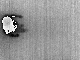

In [38]:
cp = p + '/' + tdf['camera_ts'] + '.camera.png'
ci = camera_image_from_frame(tdf)
ci.save(cp)
ci

In [34]:
ca = np.loadtxt('../2025-07-03/ir_adl/kc/24bakc/frame_2024-07-10T14_49_41.362593.csv', delimiter=',', usecols=list(range(80)), max_rows=60).reshape((60, 80))

In [35]:
ca

array([[8029., 8014., 8003., ..., 8012., 8001., 8001.],
       [8013., 8011., 8040., ..., 8029., 8003., 7976.],
       [8035., 8015., 8016., ..., 8013., 7995., 8001.],
       ...,
       [8025., 8042., 8031., ..., 8032., 8023., 8018.],
       [8052., 8039., 8044., ..., 8018., 8027., 8006.],
       [8028., 8034., 8035., ..., 8026., 8028., 8001.]])

In [36]:
can = (ca - ca.min()) / (ca.max() - ca.min())
can = 
can

array([[0.16932907, 0.12140575, 0.08626198, ..., 0.11501597, 0.0798722 ,
        0.0798722 ],
       [0.11821086, 0.11182109, 0.20447284, ..., 0.16932907, 0.08626198,
        0.        ],
       [0.1884984 , 0.12460064, 0.12779553, ..., 0.11821086, 0.06070288,
        0.0798722 ],
       ...,
       [0.15654952, 0.21086262, 0.17571885, ..., 0.17891374, 0.15015974,
        0.1341853 ],
       [0.2428115 , 0.20127796, 0.2172524 , ..., 0.1341853 , 0.1629393 ,
        0.09584665],
       [0.16613419, 0.18530351, 0.1884984 , ..., 0.15974441, 0.16613419,
        0.0798722 ]])

In [44]:
def write_image_pairs(frame_data):
    p = frame_data['camera_path']
    p = re.sub(r'\.\./', r'', p)
    p = re.sub(r'ir_adl', r'adl_image', p)
    p = re.sub(r'ir_fall', r'fall_image', p)
    os.makedirs(p, exist_ok=True)
    
    mp = p + '/' + frame_data['camera_ts'] + '.mat.png'
    mi = mat_image_from_frame(frame_data)
    mi.save(mp)

    cp = p + '/' + frame_data['camera_ts'] + '.camera.png'
    ci = camera_image_from_frame(frame_data)
    ci.save(cp)

In [46]:
for fd in validation_data_frames:
    write_image_pairs(fd)

In [47]:
for fd in test_data_frames:
    write_image_pairs(fd)

In [48]:
for fd in training_data_frames:
    write_image_pairs(fd)

In [49]:
!ls /datasets

23j-ema-originals     dogs-vs-cats	       mnist
24j-tma3	      downloads		       news20
amazon		      eurosat		       pv
amazon-reviews	      fairy-tales	       pv.tgz
amazon-reviews.tgz    fairy-tales.tgz	       sea-hero-quest.tgz
bailey		      features_3_sec_mfcc.csv  seaheroquest
caltech101	      fer-2013		       smote
cifar10		      fer-2013.tgz	       smote.tgz
coil-100	      glove.6B		       stanford-dogs-dataset
coil-100-defaced.tgz  gravitational-lenses     swedish-cities
cybersecurity	      imagenet		       tm358-copy
cybersecurity.tgz     imdb_reviews	       translation
cybersecurity.zip     iris		       treesat
deepfakes	      kvasir		       treesat-preprocessed.tgz
deepfakes.tgz	      meld


In [64]:
def add_image_path(frame_data):
    p = frame_data['camera_path']
    p = re.sub(r'\.\./', r'', p)
    p = re.sub(r'ir_adl', r'adl_image', p)
    p = re.sub(r'ir_fall', r'fall_image', p)
    p = '/datasets/bailey/' + p
    mp = p + '/' + frame_data['camera_ts'] + '.mat.png'
    cp = p + '/' + frame_data['camera_ts'] + '.camera.png'
    frame_data['camera_image_path'] = cp
    frame_data['mat_image_path'] = mp
    frame_data['mat_path'] = re.sub(r'\.\.', r'/datasets/bailey', frame_data['mat_path'])
    frame_data['camera_path'] = re.sub(r'\.\.', r'/datasets/bailey', frame_data['camera_path'])
    return frame_data

In [65]:
validation_data_frames[:5]

[{'mat_path': '../2025-07-03/pm_adl/sd/55eapspf.csv',
  'mat_ts': '2024-07-09T12:46:38.381000+01:00',
  'camera_path': '../2025-07-03/ir_adl/sd/55eapspf',
  'camera_ts': '2024-07-09T12:46:38.378145',
  'camera_image_path': '/datasets/bailey/2025-07-03/adl_image/sd/55eapspf/2024-07-09T12:46:38.378145.camera.png',
  'mat_image_path': '/datasets/bailey/2025-07-03/adl_image/sd/55eapspf/2024-07-09T12:46:38.378145.mat.png'},
 {'mat_path': '../2025-07-03/pm_adl/sd/48ealswd.csv',
  'mat_ts': '2024-07-09T12:33:04.654000+01:00',
  'camera_path': '../2025-07-03/ir_adl/sd/48ealswd',
  'camera_ts': '2024-07-09T12:33:04.663850',
  'camera_image_path': '/datasets/bailey/2025-07-03/adl_image/sd/48ealswd/2024-07-09T12:33:04.663850.camera.png',
  'mat_image_path': '/datasets/bailey/2025-07-03/adl_image/sd/48ealswd/2024-07-09T12:33:04.663850.mat.png'},
 {'mat_path': '../2025-07-03/pm_fall/fsl/16apfsl.csv',
  'mat_ts': '2024-07-18T11:29:09.768000+01:00',
  'camera_path': '../2025-07-03/ir_fall/fsl/16apfsl

In [66]:
rv = [add_image_path(fp) for fp in validation_data_frames]
rv[:3]

[{'mat_path': '/datasets/bailey/2025-07-03/pm_adl/sd/55eapspf.csv',
  'mat_ts': '2024-07-09T12:46:38.381000+01:00',
  'camera_path': '/datasets/bailey/2025-07-03/ir_adl/sd/55eapspf',
  'camera_ts': '2024-07-09T12:46:38.378145',
  'camera_image_path': '/datasets/bailey/2025-07-03/adl_image/sd/55eapspf/2024-07-09T12:46:38.378145.camera.png',
  'mat_image_path': '/datasets/bailey/2025-07-03/adl_image/sd/55eapspf/2024-07-09T12:46:38.378145.mat.png'},
 {'mat_path': '/datasets/bailey/2025-07-03/pm_adl/sd/48ealswd.csv',
  'mat_ts': '2024-07-09T12:33:04.654000+01:00',
  'camera_path': '/datasets/bailey/2025-07-03/ir_adl/sd/48ealswd',
  'camera_ts': '2024-07-09T12:33:04.663850',
  'camera_image_path': '/datasets/bailey/2025-07-03/adl_image/sd/48ealswd/2024-07-09T12:33:04.663850.camera.png',
  'mat_image_path': '/datasets/bailey/2025-07-03/adl_image/sd/48ealswd/2024-07-09T12:33:04.663850.mat.png'},
 {'mat_path': '/datasets/bailey/2025-07-03/pm_fall/fsl/16apfsl.csv',
  'mat_ts': '2024-07-18T11:29

In [76]:
with open('validation_frames.csv', 'w', newline='') as f:
    fieldnames = ['mat_path', 'mat_ts', 'camera_path', 'camera_ts', 'mat_image_path', 'camera_image_path']
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for s in rv:
        writer.writerow(
           {'mat_path': re.sub( r'2025-07-03', r'2025-07-03/data',  s['mat_path']), 
             'mat_ts': s['mat_ts'], 
             'camera_path': re.sub(r'2025-07-03', r'2025-07-03/data', s['camera_path']),
             'camera_ts': s['camera_ts'],
             'mat_image_path': re.sub(r'2025-07-03', r'2025-07-03/images', s['mat_image_path']),
             'camera_image_path': re.sub(r'2025-07-03', r'2025-07-03/images', s['camera_image_path'])            
            })

In [68]:
rt = [add_image_path(fp) for fp in test_data_frames]
rt[:3]

[{'mat_path': '/datasets/bailey/2025-07-03/pm_fall/sp/30cpsp.csv',
  'mat_ts': '2024-07-29T10:41:27.393000+01:00',
  'camera_path': '/datasets/bailey/2025-07-03/ir_fall/sp/30cpsp',
  'camera_ts': '2024-07-29T10:41:27.403563',
  'camera_image_path': '/datasets/bailey/2025-07-03/fall_image/sp/30cpsp/2024-07-29T10:41:27.403563.camera.png',
  'mat_image_path': '/datasets/bailey/2025-07-03/fall_image/sp/30cpsp/2024-07-29T10:41:27.403563.mat.png'},
 {'mat_path': '/datasets/bailey/2025-07-03/pm_adl/sd/37eabpsl.csv',
  'mat_ts': '2024-07-09T12:19:05.383000+01:00',
  'camera_path': '/datasets/bailey/2025-07-03/ir_adl/sd/37eabpsl',
  'camera_ts': '2024-07-09T12:19:05.388807',
  'camera_image_path': '/datasets/bailey/2025-07-03/adl_image/sd/37eabpsl/2024-07-09T12:19:05.388807.camera.png',
  'mat_image_path': '/datasets/bailey/2025-07-03/adl_image/sd/37eabpsl/2024-07-09T12:19:05.388807.mat.png'},
 {'mat_path': '/datasets/bailey/2025-07-03/pm_adl/sb/31fabs.csv',
  'mat_ts': '2024-08-02T13:12:17.141

In [75]:
with open('testing_frames.csv', 'w', newline='') as f:
    fieldnames = ['mat_path', 'mat_ts', 'camera_path', 'camera_ts', 'mat_image_path', 'camera_image_path']
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for s in rt:
        writer.writerow(
            {'mat_path': re.sub( r'2025-07-03', r'2025-07-03/data',  s['mat_path']), 
             'mat_ts': s['mat_ts'], 
             'camera_path': re.sub(r'2025-07-03', r'2025-07-03/data', s['camera_path']),
             'camera_ts': s['camera_ts'],
             'mat_image_path': re.sub(r'2025-07-03', r'2025-07-03/images', s['mat_image_path']),
             'camera_image_path': re.sub(r'2025-07-03', r'2025-07-03/images', s['camera_image_path'])
            })

In [70]:
rx = [add_image_path(fp) for fp in training_data_frames]
rx[:3]

[{'mat_path': '/datasets/bailey/2025-07-03/pm_adl/sa/15daclh.csv',
  'mat_ts': '2024-06-11T10:16:42.370000+01:00',
  'camera_path': '/datasets/bailey/2025-07-03/ir_adl/sa/15daclh',
  'camera_ts': '2024-06-11T10:16:42.384334',
  'camera_image_path': '/datasets/bailey/2025-07-03/adl_image/sa/15daclh/2024-06-11T10:16:42.384334.camera.png',
  'mat_image_path': '/datasets/bailey/2025-07-03/adl_image/sa/15daclh/2024-06-11T10:16:42.384334.mat.png'},
 {'mat_path': '/datasets/bailey/2025-07-03/pm_adl/sd/56dairsbf.csv',
  'mat_ts': '2024-06-11T11:45:20.407000+01:00',
  'camera_path': '/datasets/bailey/2025-07-03/ir_adl/sd/56dairsbf',
  'camera_ts': '2024-06-11T11:45:20.421703',
  'camera_image_path': '/datasets/bailey/2025-07-03/adl_image/sd/56dairsbf/2024-06-11T11:45:20.421703.camera.png',
  'mat_image_path': '/datasets/bailey/2025-07-03/adl_image/sd/56dairsbf/2024-06-11T11:45:20.421703.mat.png'},
 {'mat_path': '/datasets/bailey/2025-07-03/pm_adl/kc/24bakc.csv',
  'mat_ts': '2024-07-10T14:49:41

In [73]:
with open('training_frames.csv', 'w', newline='') as f:
    fieldnames = ['mat_path', 'mat_ts', 'camera_path', 'camera_ts', 'mat_image_path', 'camera_image_path']
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for s in rx:
        writer.writerow(
            {'mat_path': re.sub( r'2025-07-03', r'2025-07-03/data',  s['mat_path']), 
             'mat_ts': s['mat_ts'], 
             'camera_path': re.sub(r'2025-07-03', r'2025-07-03/data', s['camera_path']),
             'camera_ts': s['camera_ts'],
             'mat_image_path': re.sub(r'2025-07-03', r'2025-07-03/images', s['mat_image_path']),
             'camera_image_path': re.sub(r'2025-07-03', r'2025-07-03/images', s['camera_image_path'])
            })

In [72]:
re.sub(r'2025-07-03', r'2025-07-03/data', '/datasets/bailey/2025-07-03/pm_adl/sa/15daclh.csv')

'/datasets/bailey/2025-07-03/data/pm_adl/sa/15daclh.csv'